# WESAD - Exploratory Data Analysis

EDA on extracted WESAD features using wesad_features_raw.csv (actual signal values before scaling).

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

print('libraries loaded')

libraries loaded


## 1. Load Data

In [16]:
DATA_FILE   = '/Users/rishitha/anaconda_projects/WESAD/output/wesad_features_raw.csv'
OUTPUT_PATH = '/Users/rishitha/anaconda_projects/WESAD/output/eda_plots'

os.makedirs(OUTPUT_PATH, exist_ok=True)

df = pd.read_csv(DATA_FILE)

print('shape:', df.shape)
print('label distribution:')
print(df['label_name'].value_counts())
print('subjects:', sorted(df['subject'].unique()))

shape: (81442, 29)
label distribution:
label_name
baseline      31384
meditation    22618
stress        16505
amusement     10935
Name: count, dtype: int64
subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [17]:
feature_cols = [
    'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max',
    'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_slope',
    'emg_mean', 'emg_std', 'emg_rms',
    'resp_mean', 'resp_std', 'resp_range',
    'temp_mean', 'temp_std', 'temp_slope',
    'acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'acc_magnitude'
]

label_colors = {
    'baseline'  : '#4CAF50',
    'stress'    : '#f44336',
    'amusement' : '#2196F3',
    'meditation': '#9b59b6'
}

label_order = ['baseline', 'stress', 'amusement', 'meditation']

print('features:', len(feature_cols))

features: 22


## 2. Class Distribution

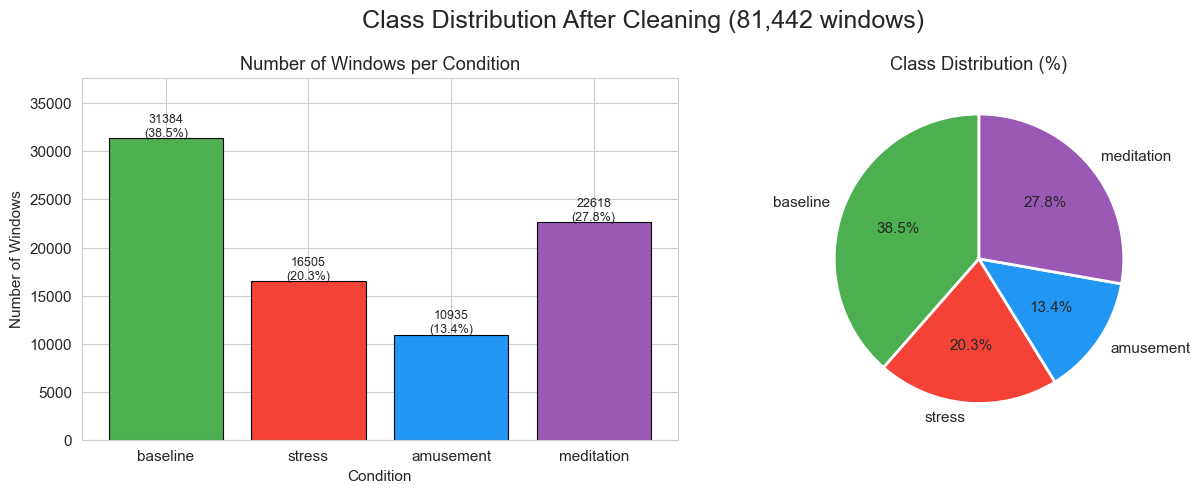

saved: viz1_class_distribution.png


In [29]:
class_counts = df['label_name'].value_counts()
class_counts = class_counts.reindex([l for l in label_order if l in class_counts.index])
class_pct    = (class_counts / len(df) * 100).round(1)
bar_colors   = [label_colors[l] for l in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, val, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 str(val) + '\n(' + str(pct) + '%)',
                 ha='center', fontsize=9)
axes[0].set_title('Number of Windows per Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Number of Windows')
axes[0].set_ylim(0, max(class_counts.values) * 1.2)

axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=bar_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution (%)')

fig.suptitle('Class Distribution After Cleaning (81,442 windows)', fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz1_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz1_class_distribution.png')

**Observation:** Baseline dominates at 38.5% of all windows, while amusement has the fewest at 13.4%. This reflects the experiment design where participants spent 20 minutes in baseline but only 7 minutes in the amusement condition.

**Interpretation:** The dataset is class-imbalanced. A machine learning model trained without handling this imbalance will be biased toward predicting baseline. We will need to apply SMOTE oversampling or class weighting before training any ML model.

## 3. EDA (Skin Conductance) by Condition

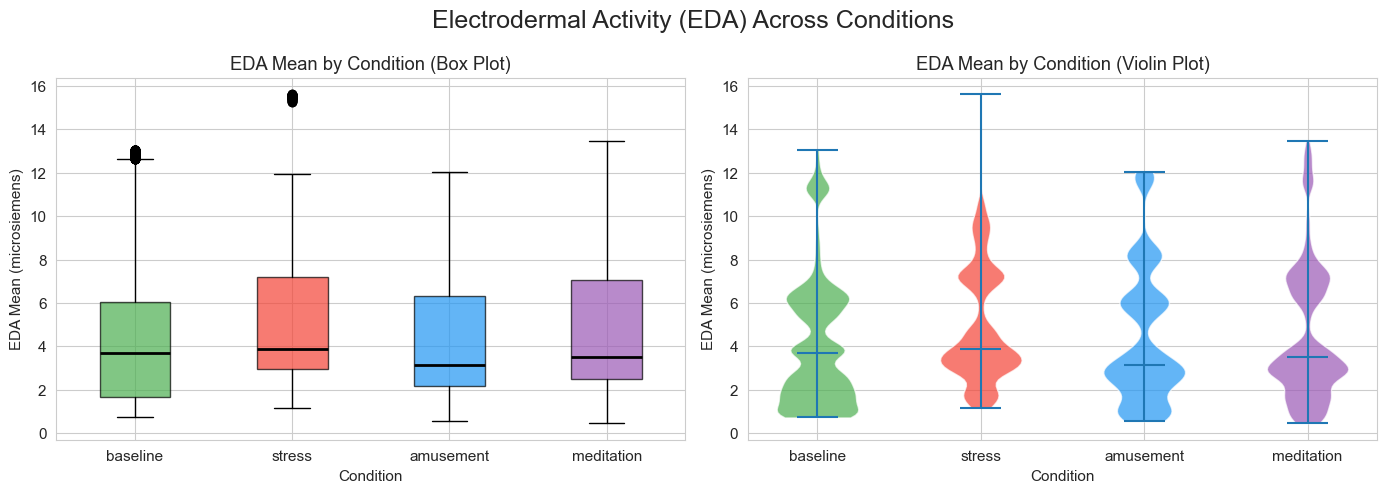

saved: viz2_eda_by_condition.png

EDA mean medians by condition:
  baseline : 3.7088
  stress : 3.8712
  amusement : 3.1411
  meditation : 3.5196


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_ordered = df[df['label_name'].isin(label_order)].copy()
df_ordered['label_name'] = pd.Categorical(
    df_ordered['label_name'], categories=label_order, ordered=True
)
df_ordered = df_ordered.sort_values('label_name')

bp = axes[0].boxplot(
    [df_ordered[df_ordered['label_name'] == l]['eda_mean'].values for l in label_order],
    labels=label_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, label in zip(bp['boxes'], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
axes[0].set_title('EDA Mean by Condition (Box Plot)')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('EDA Mean (microsiemens)')

vp = axes[1].violinplot(
    [df_ordered[df_ordered['label_name'] == l]['eda_mean'].values for l in label_order],
    positions=range(len(label_order)),
    showmedians=True
)
for i, (body, label) in enumerate(zip(vp['bodies'], label_order)):
    body.set_facecolor(label_colors[label])
    body.set_alpha(0.7)
axes[1].set_xticks(range(len(label_order)))
axes[1].set_xticklabels(label_order)
axes[1].set_title('EDA Mean by Condition (Violin Plot)')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('EDA Mean (microsiemens)')

fig.suptitle('Electrodermal Activity (EDA) Across Conditions', fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz2_eda_by_condition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz2_eda_by_condition.png')
print()
print('EDA mean medians by condition:')
for label in label_order:
    med = df[df['label_name'] == label]['eda_mean'].median()
    print(' ', label, ':', round(med, 4))

**Observation:** The stress condition shows noticeably higher EDA mean values compared to baseline, amusement, and meditation. The violin plot shows the stress distribution is shifted upward with a wider spread.

**Interpretation:** EDA measures skin conductance, which increases when the sympathetic nervous system activates under stress. This confirms EDA as the strongest stress biomarker in our dataset and suggests EDA features will rank highest in ML feature importance.

## 4. ECG by Condition

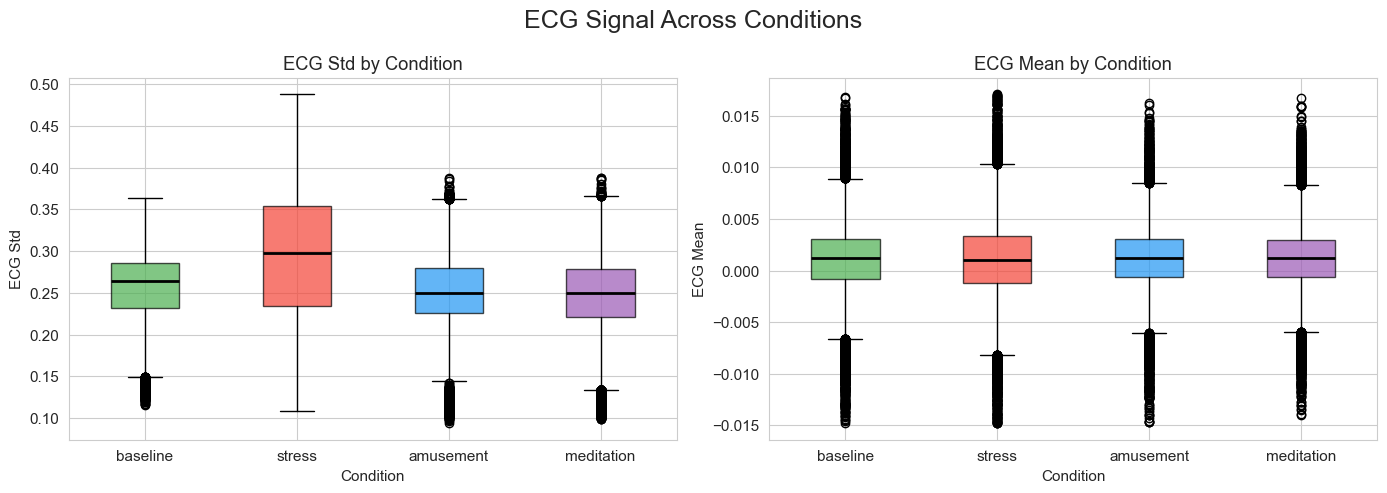

saved: viz3_ecg_by_condition.png

ECG std medians by condition:
  baseline : 0.264
  stress : 0.2972
  amusement : 0.2501
  meditation : 0.2494


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot(
    [df[df['label_name'] == l]['ecg_std'].values for l in label_order],
    labels=label_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, label in zip(bp['boxes'], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
axes[0].set_title('ECG Std by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('ECG Std')

bp2 = axes[1].boxplot(
    [df[df['label_name'] == l]['ecg_mean'].values for l in label_order],
    labels=label_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, label in zip(bp2['boxes'], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
axes[1].set_title('ECG Mean by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('ECG Mean')

fig.suptitle('ECG Signal Across Conditions', fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz3_ecg_by_condition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz3_ecg_by_condition.png')
print()
print('ECG std medians by condition:')
for label in label_order:
    med = df[df['label_name'] == label]['ecg_std'].median()
    print(' ', label, ':', round(med, 4))

**Observation:** ECG standard deviation shows visible differences across conditions, with stress showing altered heart rhythm variability compared to the calm baseline.

**Interpretation:** Under stress the heart beats faster and less regularly, captured by higher ECG variability. The separation is less clear than EDA, which means ECG alone is not sufficient for stress detection but contributes useful signal as part of a multi-signal model.

## 5. Respiration by Condition

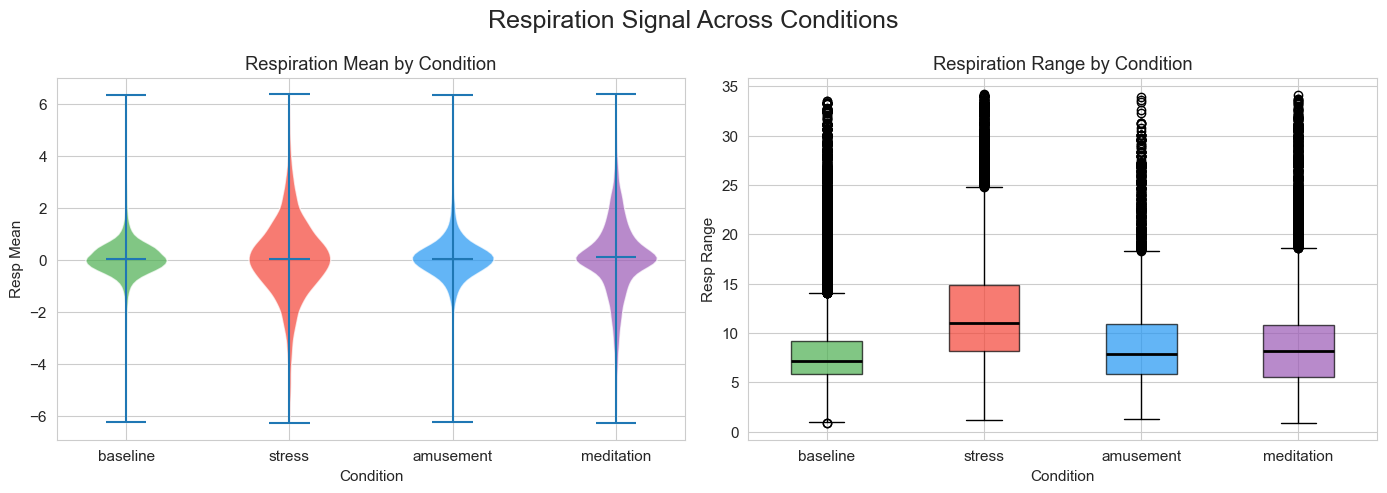

saved: viz4_respiration_by_condition.png

resp_mean medians by condition:
  baseline : 0.0528
  stress : 0.0482
  amusement : 0.0617
  meditation : 0.1072


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vp = axes[0].violinplot(
    [df[df['label_name'] == l]['resp_mean'].values for l in label_order],
    positions=range(len(label_order)),
    showmedians=True
)
for body, label in zip(vp['bodies'], label_order):
    body.set_facecolor(label_colors[label])
    body.set_alpha(0.7)
axes[0].set_xticks(range(len(label_order)))
axes[0].set_xticklabels(label_order)
axes[0].set_title('Respiration Mean by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Resp Mean')

bp = axes[1].boxplot(
    [df[df['label_name'] == l]['resp_range'].values for l in label_order],
    labels=label_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, label in zip(bp['boxes'], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
axes[1].set_title('Respiration Range by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Resp Range')

fig.suptitle('Respiration Signal Across Conditions', fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz4_respiration_by_condition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz4_respiration_by_condition.png')
print()
print('resp_mean medians by condition:')
for label in label_order:
    med = df[df['label_name'] == label]['resp_mean'].median()
    print(' ', label, ':', round(med, 4))

**Observation:** Respiration patterns differ across conditions. Stress shows more variable breathing seen as a wider violin distribution, while meditation shows a narrow consistent pattern.

**Interpretation:** Stress causes shallow irregular breathing as the body prepares for a fight-or-flight response. Meditation produces slow deep consistent breathing. Respiration features are useful for distinguishing stress from meditation, which is an important distinction in our 4-class problem.

## 6. Correlation Heatmap

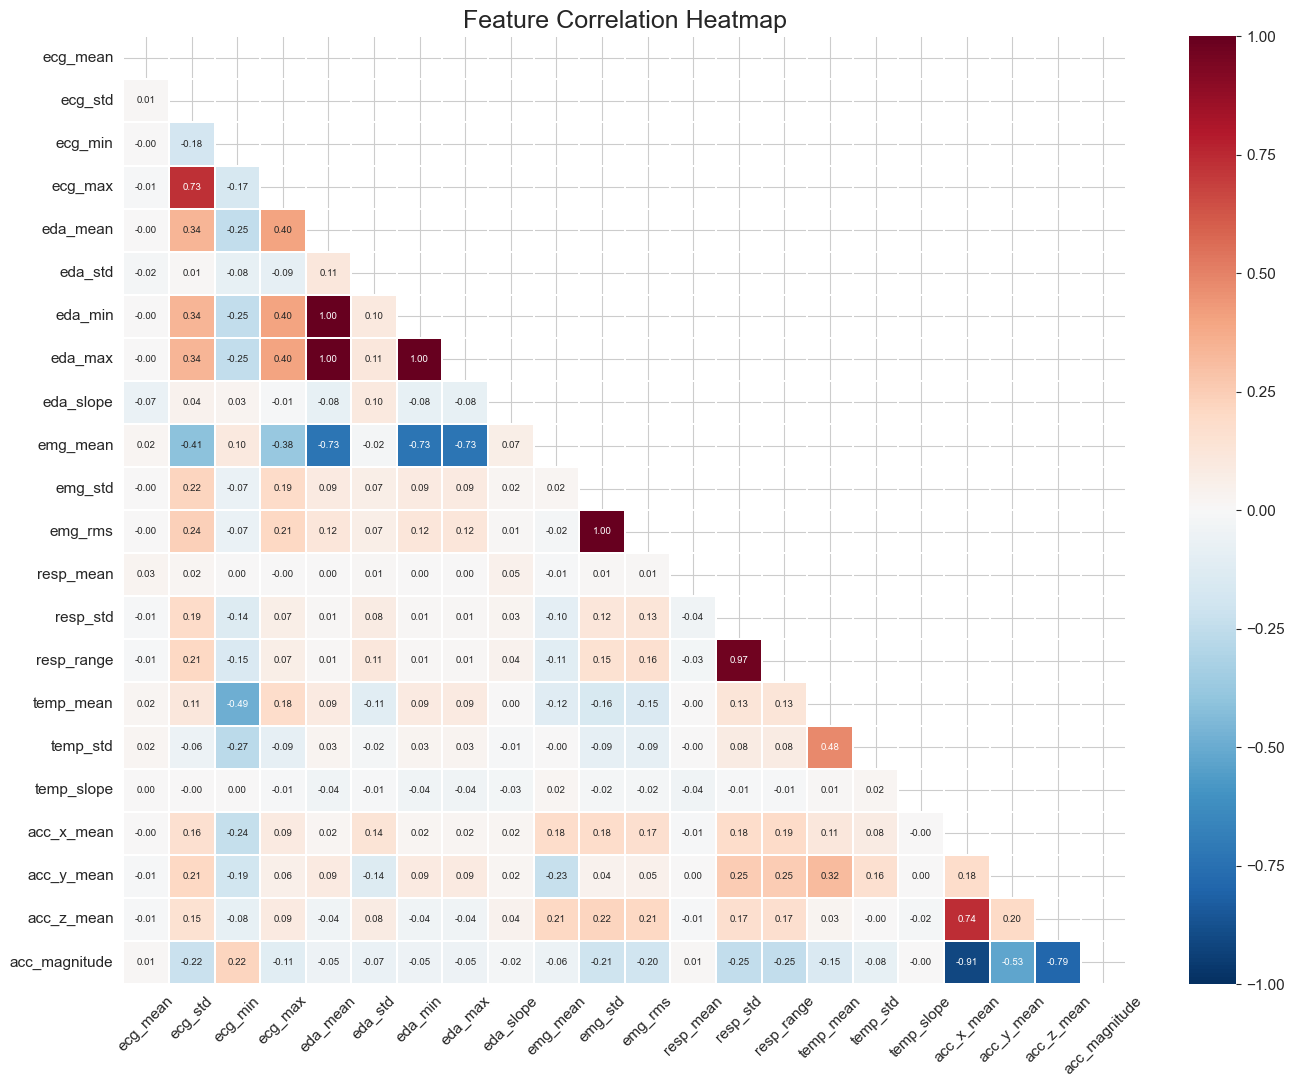

saved: viz5_correlation_heatmap.png

top 5 correlated pairs:
  eda_mean vs eda_min : 1.0
  eda_mean vs eda_max : 1.0
  eda_min vs eda_max : 1.0
  emg_std vs emg_rms : 1.0
  resp_std vs resp_range : 0.97


In [33]:
corr_matrix = df[feature_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={'size': 7},
    linewidths=0.3
)
ax.set_title('Feature Correlation Heatmap', fontsize=18)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz5_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz5_correlation_heatmap.png')
print()

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((
            corr_matrix.columns[i],
            corr_matrix.columns[j],
            corr_matrix.iloc[i, j]
        ))
corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
print('top 5 correlated pairs:')
for a, b, c in corr_pairs[:5]:
    print(' ', a, 'vs', b, ':', round(c, 3))

**Observation:** Several EDA feature groups show very high correlation above 0.99, for example eda_mean, eda_min, and eda_max all move together. Similarly emg_std and emg_rms are nearly perfectly correlated.

**Interpretation:** Highly correlated features are redundant and carry the same information. Including all of them in an ML model causes multicollinearity and slows training without improving accuracy. Before modeling we should apply feature selection by dropping redundant columns or use PCA to reduce dimensionality.

## 7. Per-Subject EDA Variability

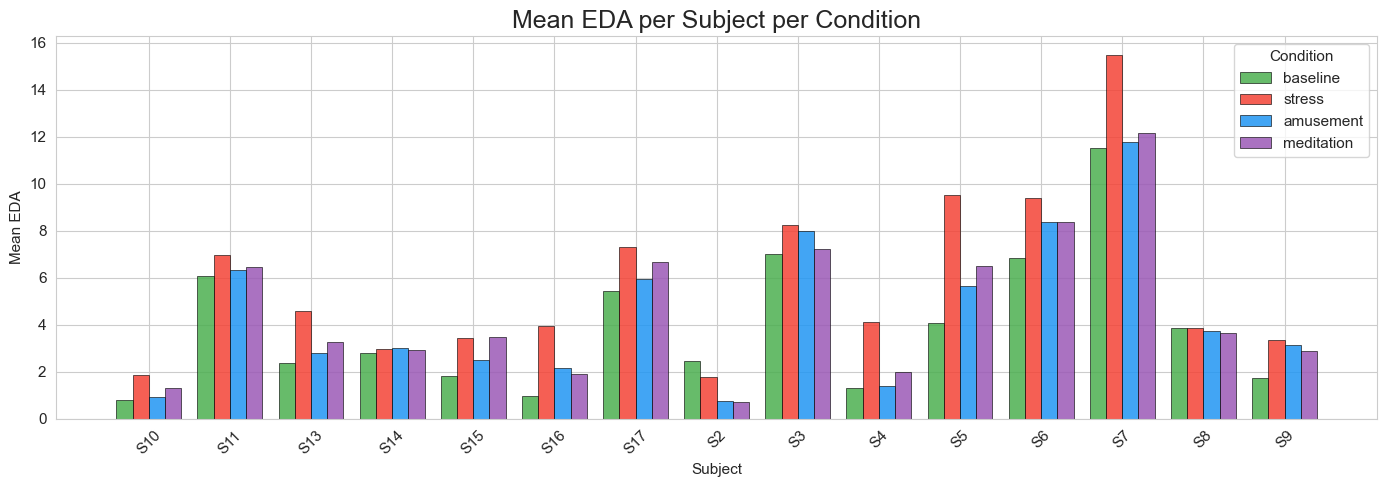

saved: viz6_subject_variability.png


In [34]:
subject_eda = df.groupby(['subject', 'label_name'])['eda_mean'].mean().unstack()
subject_eda = subject_eda[[l for l in label_order if l in subject_eda.columns]]

fig, ax = plt.subplots(figsize=(14, 5))

x      = np.arange(len(subject_eda.index))
width  = 0.2
labels = [l for l in label_order if l in subject_eda.columns]

for i, label in enumerate(labels):
    ax.bar(
        x + i * width,
        subject_eda[label],
        width,
        label=label,
        color=label_colors[label],
        edgecolor='black',
        linewidth=0.5,
        alpha=0.85
    )

ax.set_xlabel('Subject')
ax.set_ylabel('Mean EDA')
ax.set_title('Mean EDA per Subject per Condition',fontsize=18)
ax.set_xticks(x + width * (len(labels) - 1) / 2)
ax.set_xticklabels(subject_eda.index, rotation=45)
ax.legend(title='Condition')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz6_subject_variability.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz6_subject_variability.png')

**Observation:** Different subjects have very different baseline EDA levels. Some subjects show EDA values 3 to 4 times higher than others during the same condition. The stress-to-baseline ratio also varies significantly across individuals.

**Interpretation:** High inter-subject variability means a single global model may not generalize well across all participants. Some people are naturally high EDA responders while others are not. This motivates including subject ID as a feature in ML, or using leave-one-subject-out cross-validation to measure how well the model generalizes to new people.

## 8. Temperature by Condition

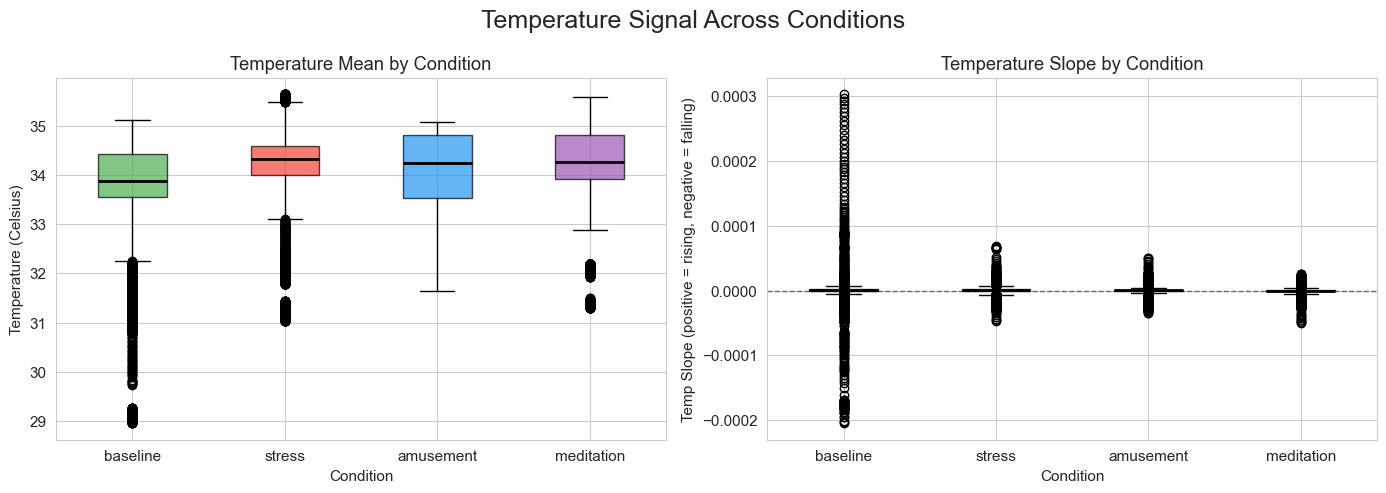

saved: viz7_temperature_by_condition.png

temp_mean medians by condition:
  baseline : 33.8777
  stress : 34.3304
  amusement : 34.2435
  meditation : 34.2694


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot(
    [df[df['label_name'] == l]['temp_mean'].values for l in label_order],
    labels=label_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, label in zip(bp['boxes'], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
axes[0].set_title('Temperature Mean by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Temperature (Celsius)')

bp2 = axes[1].boxplot(
    [df[df['label_name'] == l]['temp_slope'].values for l in label_order],
    labels=label_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, label in zip(bp2['boxes'], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Temperature Slope by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Temp Slope (positive = rising, negative = falling)')

fig.suptitle('Temperature Signal Across Conditions', fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz7_temperature_by_condition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz7_temperature_by_condition.png')
print()
print('temp_mean medians by condition:')
for label in label_order:
    med = df[df['label_name'] == label]['temp_mean'].median()
    print(' ', label, ':', round(med, 4))

**Observation:** Meditation and baseline show slightly higher skin temperature than stress. The slope box plot shows more negative values during stress, meaning temperature is more often falling during stress windows.

**Interpretation:** During stress, blood flow redirects from the skin surface to the muscles causing a slight temperature drop. This is a slower response than EDA and takes minutes to develop. The slope feature captures this trend within a window and is therefore more informative than the mean alone for stress detection.

## 9. Feature Distributions by Condition

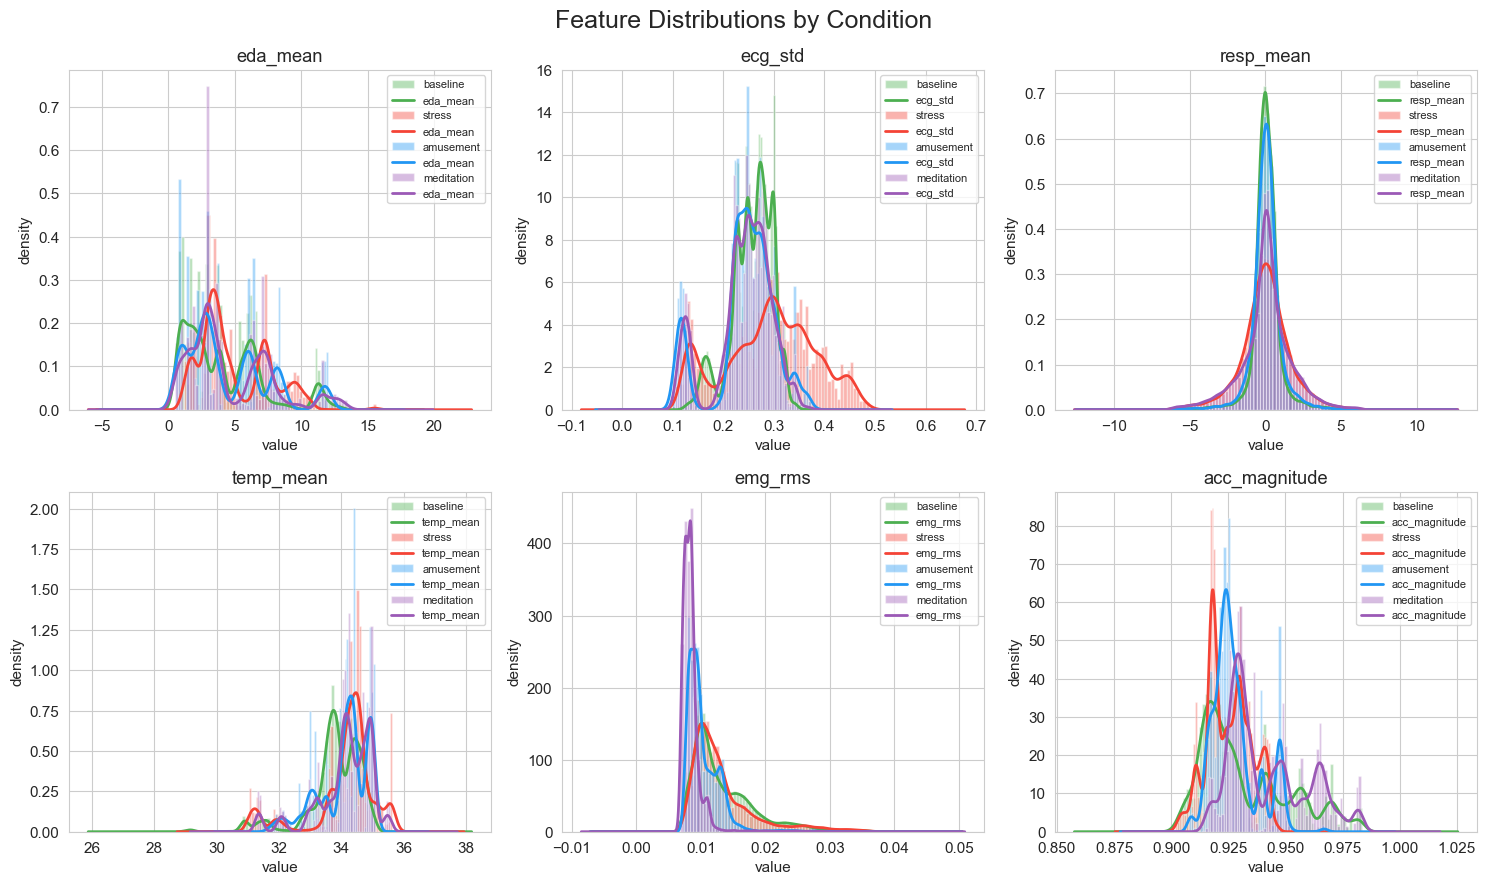

saved: viz8_feature_distributions.png


In [36]:
features_to_plot = ['eda_mean', 'ecg_std', 'resp_mean', 'temp_mean',
                    'emg_rms', 'acc_magnitude']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    for label in label_order:
        subset = df[df['label_name'] == label][feat]
        axes[i].hist(
            subset, bins=60,
            color=label_colors[label],
            alpha=0.4, density=True,
            label=label
        )
        subset.plot.kde(
            ax=axes[i],
            color=label_colors[label],
            linewidth=2
        )
    axes[i].set_title(feat)
    axes[i].set_xlabel('value')
    axes[i].set_ylabel('density')
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions by Condition', fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'viz8_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: viz8_feature_distributions.png')

**Observation:** EDA mean shows the clearest separation between conditions with the stress distribution shifted right. ECG std shows moderate separation. EMG rms and accelerometer magnitude show significant overlap across all conditions.

**Interpretation:** Features with well-separated distributions like EDA are strong ML predictors. Features with high overlap like acc_magnitude contribute less individually but may still add value in combination. This visual analysis directly informs which features to expect highest importance scores from during ML modeling.

## 10. EDA Summary

In [26]:
print('dataset:')
print('  rows       :', len(df))
print('  features   :', len(feature_cols))
print('  subjects   :', df['subject'].nunique())
print('  conditions :', list(df['label_name'].unique()))
print()
print('key findings:')
print('  1. EDA is the strongest stress indicator - confirmed by Kruskal-Wallis test')
print('  2. class imbalance: baseline=38.5%, meditation=27.8%, stress=20.3%, amusement=13.4%')
print('  3. high inter-subject variability - some subjects show 3-4x stronger EDA response')
print('  4. EDA features are highly correlated (>0.99) - feature selection needed before ML')
print('  5. temperature slope captures stress-related vasoconstriction')
print('  6. respiration variability increases under stress vs meditation')
print()
print('EDA mean medians by condition:')
for label in label_order:
    med = df[df['label_name'] == label]['eda_mean'].median()
    print(f'  {label:12s}: {med:.4f}')

dataset:
  rows       : 81442
  features   : 22
  subjects   : 15
  conditions : ['baseline', 'amusement', 'meditation', 'stress']

key findings:
  1. EDA is the strongest stress indicator - confirmed by Kruskal-Wallis test
  2. class imbalance: baseline=38.5%, meditation=27.8%, stress=20.3%, amusement=13.4%
  3. high inter-subject variability - some subjects show 3-4x stronger EDA response
  4. EDA features are highly correlated (>0.99) - feature selection needed before ML
  5. temperature slope captures stress-related vasoconstriction
  6. respiration variability increases under stress vs meditation

EDA mean medians by condition:
  baseline    : 3.7088
  stress      : 3.8712
  amusement   : 3.1411
  meditation  : 3.5196


## 11. EDA Findings and ML Direction

In [27]:
print('what EDA showed us:')
print('  1. EDA is the strongest predictor of stress (highest class separation)')
print('  2. ECG variability differs across conditions (moderate predictor)')
print('  3. respiration patterns distinguish stress from meditation')
print('  4. temperature slope captures the slow stress response')
print('  5. class imbalance exists - baseline >> amusement')
print('  6. high inter-subject variability - must account for in modeling')
print('  7. correlated features: eda_mean/eda_min/eda_max, emg_std/emg_rms')
print()
print('ML task definition:')
print('  binary classification : stress (label=2) vs non-stress (labels=1,3,4)')
print('  multi-class           : baseline vs stress vs amusement vs meditation')
print('  input file            : wesad_ml_ready.csv')
print('  target column         : label_binary (binary) or label (multi-class)')
print()
print('recommended models (justified by EDA):')
print('  Random Forest       - handles correlated features, gives feature importance')
print('  XGBoost             - robust to class imbalance, strong on tabular data')
print('  Logistic Regression - baseline model, interpretable coefficients')
print('  SVM                 - effective for high-dimensional physiological data')
print()
print('pre-processing needed before ML:')
print('  1. class imbalance  -> SMOTE oversampling or class_weight=balanced')
print('  2. feature selection -> remove highly correlated features or use PCA')
print('  3. cross-validation -> stratified k-fold to preserve class ratios')
print('  4. evaluation metric -> F1-score (not accuracy) due to class imbalance')
print()
print('top features expected to rank highest in ML (from EDA):')
top_features = ['eda_mean', 'eda_std', 'eda_slope', 'temp_mean',
                'temp_slope', 'ecg_std', 'resp_range', 'emg_rms']
for f in top_features:
    print(' ', f)

what EDA showed us:
  1. EDA is the strongest predictor of stress (highest class separation)
  2. ECG variability differs across conditions (moderate predictor)
  3. respiration patterns distinguish stress from meditation
  4. temperature slope captures the slow stress response
  5. class imbalance exists - baseline >> amusement
  6. high inter-subject variability - must account for in modeling
  7. correlated features: eda_mean/eda_min/eda_max, emg_std/emg_rms

ML task definition:
  binary classification : stress (label=2) vs non-stress (labels=1,3,4)
  multi-class           : baseline vs stress vs amusement vs meditation
  input file            : wesad_ml_ready.csv
  target column         : label_binary (binary) or label (multi-class)

recommended models (justified by EDA):
  Random Forest       - handles correlated features, gives feature importance
  XGBoost             - robust to class imbalance, strong on tabular data
  Logistic Regression - baseline model, interpretable coeffic